# Spatially Targeted Grooming Analysis

In this notebook we will be analyzing grooming data in response to optogenetic activation of different 23B neurons. These results are all outlined in Figure 5 of the accompanying manuscript. Helper functions that were used to clean and organize the data from raw tracking data to the data file read below can be found in contacts.py

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ttest_rel, wilcoxon

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))
from contacts import get_joint_distances, get_closest_joint

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


Reading in a subset of the data for all the trials includeded in the dataset. 

Note that this is a random sample (1%) of a very large dataframe so the figures will not be the exact same as those in our paper. If you are interested in all of the data used for the analysis and figures of the accompanying manuscript please contact tuthill@uw.edu.

In [ ]:
df = pd.read_parquet('../data/grooming_data_01_sample.parquet')

## Do they groom more with the laser on?

### Individual Examples

In [4]:
#Example traces
single_empty_df = df.query('flyid == "2.21.25 Fly 1_0" & repnum == "2"')
single_s_df = df.query('flyid == "3.14.25 Fly 1_0" & repnum == "1"')
single_r_df = df.query('flyid == "4.11.25 Fly 3_0" & repnum == "2"')

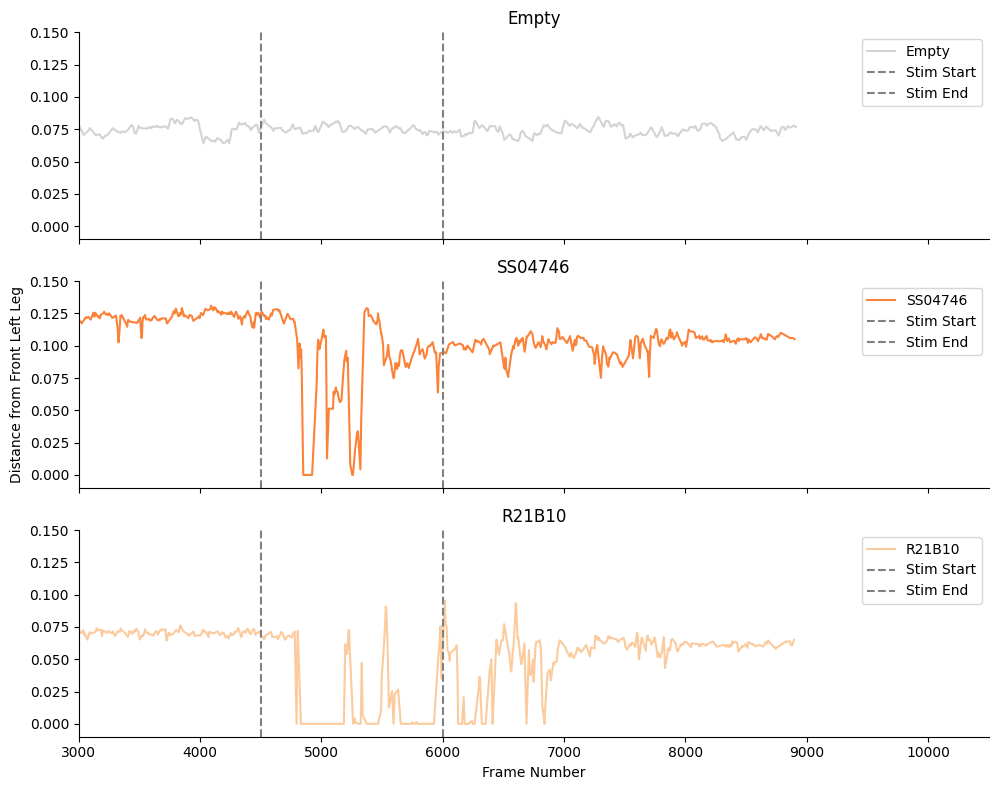

In [5]:
from scipy.ndimage import gaussian_filter1d
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, sharey=True)



# # Apply Gaussian smoothing to the distance_capped values
single_empty_df['smoothed_distance_capped'] = gaussian_filter1d(single_empty_df['distance_capped'], sigma=10)
single_s_df['smoothed_distance_capped'] = gaussian_filter1d(single_s_df['distance_capped'], sigma=10)
single_r_df['smoothed_distance_capped'] = gaussian_filter1d(single_r_df['distance_capped'], sigma=10)



# Plot for single_empty_df
sns.lineplot(ax=axes[0], data=single_empty_df, x='fnum', y='distance_capped', color='lightgray', label='Empty')
axes[0].set_title('Empty')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Plot for single_s_df
sns.lineplot(ax=axes[1], data=single_s_df, x='fnum', y='distance_capped', color='#fb8239', label='SS04746')
axes[1].set_title('SS04746')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Plot for single_r_df
sns.lineplot(ax=axes[2], data=single_r_df, x='fnum', y='distance_capped', color='#fbcb9e', label='R21B10')
axes[2].set_title('R21B10')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

# Set common y-limits
y_min = min(single_empty_df['smoothed_distance_capped'].min(), 
            single_s_df['smoothed_distance_capped'].min(), 
            single_r_df['smoothed_distance_capped'].min())
y_max = max(single_empty_df['smoothed_distance_capped'].max(), 
            single_s_df['smoothed_distance_capped'].max(), 
            single_r_df['smoothed_distance_capped'].max())
for ax in axes:
    ax.set_ylim(y_min, y_max)

# Add vertical lines and labels
for ax in axes:
    ax.axvline(x=4500, color='gray', linestyle='--', label='Stim Start')
    ax.axvline(x=6000, color='gray', linestyle='--', label='Stim End')
    ax.legend()

axes[2].set_xlim(3000, 10500)
axes[2].set_ylim(-0.01, 0.15)
axes[2].set_xlabel('Frame Number')
axes[1].set_ylabel('Distance from Front Left Leg')

axes[0].set_ylabel('')
axes[2].set_ylabel('')
plt.tight_layout()
plt.show()

How about multiple traces per condition? Below is an ethogram with 15 trials per condition. Here we are quantifying the number of sweeps per trial. Sweeps are shown in navy, and non-sweep behavior (including no movement) is in gray. 

Note that making this ethogram takes a few minutes to run

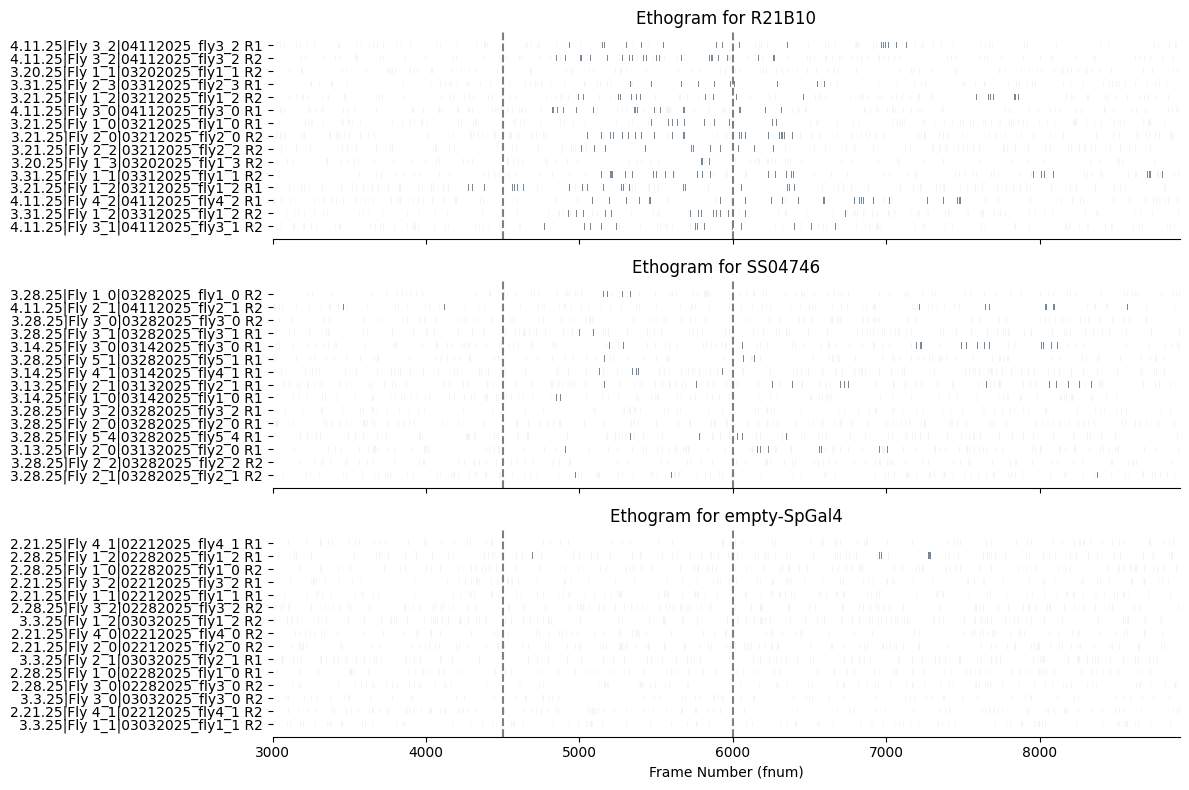

In [ ]:
df['is_sweep'] = df['sweep_number_new'].apply(lambda x: 1 if x > 0 else 0)

# Define a color map for is_contact
color_map = {True: 'lightslategray', False: 'whitesmoke'}

# Group the dataframe by genotype
grouped = df.groupby('genotype')
np.random.seed(20)  # For reproducibility of random sampling
# Create a figure and axes for the plots
fig, axes = plt.subplots(len(grouped), 1, figsize=(12, 8), sharex=True)

# Iterate over each genotype group
for ax, (genotype, group) in zip(axes, grouped):
    # Get unique fullfile values for y-axis
    unique_files = group['fullfile'].unique()
    unique_files = [file for file in unique_files if 'R3' not in file]
    unique_files = np.random.choice(unique_files, size=15,replace=False)
    file_to_y = {file: idx for idx, file in enumerate(unique_files)}
    group = group.query('fullfile in @unique_files')
    # Plot for each row in the group
    for _, row in group.iterrows():
        ax.barh(
            y=file_to_y[row['fullfile']],
            width=1,
            height=0.5,
            left=row['fnum'],
            color=color_map[row['is_sweep']],
            edgecolor='none'
        )

    # Set title and y-axis labels
    ax.set_title(f'Ethogram for {genotype}')
    ax.set_yticks(range(len(unique_files)))
    ax.set_yticklabels(unique_files)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.axvline(x=4500, color='gray', linestyle='--', label='Stim Start')
    ax.axvline(x=6000, color='gray', linestyle='--', label='Stim End')

# Set common labels and limits
axes[-1].set_xlabel('Frame Number (fnum)')
axes[-1].set_xlim(3000, df['fnum'].max())

plt.tight_layout()
plt.show()


Ok now grouping all the data together - does this behavior result persist across all the trials?

In [7]:
stim_df = df.groupby(['genotype','fly','flyid','repnum',"laser", "sweep_number_new"]).size().reset_index(name='length')  
stim_df = stim_df.query('sweep_number_new > 0')

#Reformatting the df to calculate the number of grooming sweeps per trial
count_df = stim_df.groupby(['genotype','fly','flyid','repnum',"laser"]).size().reset_index(name='count')

In [8]:
# Get all unique combinations of (flyid, repnum) from df
unique_combinations = df[['genotype','fly','flyid','repnum']].drop_duplicates()
order = ['prestim', 'stim', 'poststim']
# Create a DataFrame with all possible combinations of (flyid, repnum, laser_paradigm)
all_combinations = (
    unique_combinations.assign(key=1)
    .merge(pd.DataFrame({'laser': order, 'key': 1}), on='key')
    .drop(columns='key')
)

# Merge with count_df to find missing rows
merged_df = all_combinations.merge(count_df, on=['genotype','fly','flyid','repnum', 'laser'], how='left')

# Fill missing rows with count = 0
merged_df['count'] = merged_df['count'].fillna(0).astype(int)

# Update count_df with the complete data
count_df = merged_df

In [9]:
# Function to test significance between laser_paradigm conditions within each genotype
def test_significance(data, genotypes, conditions, 
                    cond_colum = 'laser', column='count'):
    results = []
    for genotype in genotypes:
        subset = data[data['genotype'] == genotype]
        for i in range(len(conditions) - 1):
            for j in range(i + 1, len(conditions)):
                cond1 = subset[subset[cond_colum] == conditions[i]][column]
                cond2 = subset[subset[cond_colum] == conditions[j]][column]
                
                # Perform paired t-test
                t_stat, p_value = ttest_rel(cond1, cond2, nan_policy='omit')
                
                # Alternatively, use Wilcoxon signed-rank test for non-parametric data
                # t_stat, p_value = wilcoxon(cond1, cond2)
                
                results.append({
                    'genotype': genotype,
                    'condition_1': conditions[i],
                    'condition_2': conditions[j],
                    't_stat': t_stat,
                    'p_value': p_value
                })
    return results

# Define genotypes and laser_paradigm conditions
genotypes = count_df['genotype'].unique()
conditions = ['prestim', 'stim', 'poststim']

# Perform the test
significance_results = test_significance(count_df, genotypes, conditions)

# Display results
results_df = pd.DataFrame(significance_results)

results_df['is_significant'] = results_df['p_value'] < 0.05

results_df

,genotype,condition_1,condition_2,t_stat,p_value,is_significant
0,empty-SpGal4,prestim,stim,-1.000000,3.203637e-01,False
1,empty-SpGal4,prestim,poststim,-1.000000,3.203637e-01,False
2,empty-SpGal4,stim,poststim,-1.000000,3.203637e-01,False
3,R21B10,prestim,stim,-13.533662,1.820520e-21,True
4,R21B10,prestim,poststim,-9.923434,4.082888e-15,True
5,R21B10,stim,poststim,2.073279,4.172531e-02,True
6,SS04746,prestim,stim,-7.717656,1.062985e-11,True
7,SS04746,prestim,poststim,-6.974631,3.764715e-10,True
8,SS04746,stim,poststim,-3.177039,1.995936e-03,True


In [10]:
#Setting a color palette for the different laser paradigms
stim_dict = {
    'prestim':'#D3D3D3',
    'stim':'#C85250',
    'poststim':'#F7BEC0',
}

In [11]:
# Group by laser trial and sweep number, then calculate the number of unique sweeps per trial
sweeps_per_trial = df.groupby(['genotype','fly','flyid','repnum','laser', 'sweep_number_new']).size().reset_index(name='count')
sweeps_per_trial = sweeps_per_trial.query('sweep_number_new > 0')
# Calculate the total duration of the laser being on in seconds for each trial
laser_duration_seconds = 1500 / 300  # 1500 frames at 300 fps

# Calculate the frequency of sweeps in Hz for each laser trial
sweep_frequency_hz = sweeps_per_trial.groupby(['genotype','fly','flyid','repnum','laser'])['sweep_number_new'].nunique() / laser_duration_seconds
sweep_frequency_hz = sweep_frequency_hz.reset_index()

all_combinations = (
    unique_combinations.assign(key=1)
    .merge(pd.DataFrame({'laser': order, 'key': 1}), on='key')
    .drop(columns='key')
)

# Merge with count_df to find missing rows
merged_df = all_combinations.merge(sweep_frequency_hz, on=['genotype','fly','flyid','repnum', 'laser'], how='left')

# Fill missing rows with count = 0
merged_df['sweep_count'] = merged_df['sweep_number_new'].fillna(0).astype(float)

# Update count_df with the complete data
sweep_frequency_hz = merged_df


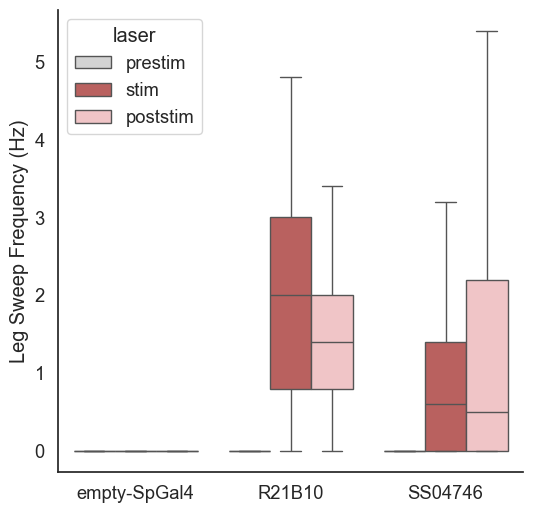

In [12]:
order = ['prestim', 'stim', 'poststim']
sweep_frequency_hz['laser'] = pd.Categorical(sweep_frequency_hz['laser'], categories=order, ordered=True)
sns.set(style='white', font_scale =1.2)
fig,ax = plt.subplots(figsize=(6,6))

sns.boxplot(x='genotype', y='sweep_count', data = sweep_frequency_hz,
                hue='laser', palette=stim_dict, ax=ax,showfliers=False)
ax.set_ylabel('Leg Sweep Frequency (Hz)')   
ax.set_xlabel('')

# Remove the top and right boundary of the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### How does the frequency of grooming vary with time?

This next cell make take 3-5 minutes to run to calculate the frequency over time

In [13]:
def calculate_sweep_frequency_through_time(df, window_size=300, step_size=300):
    """
    Calculate the frequency of sweeps through time using a sliding window analysis.

    Args:
        df (pd.DataFrame): Input DataFrame containing sweep data.
        window_size (int): Size of the sliding window in frames (default is 300 frames = 1 second).
        step_size (int): Step size for the sliding window (default is 300 frames = 1 second).

    Returns:
        pd.DataFrame: DataFrame with sweep frequency through time for each unique trial.
    """
    results = []

    # Group by unique trials
    grouped = df.groupby(['genotype', 'fly', 'flyid', 'repnum'])

    for (genotype, fly, flyid, repnum), group in grouped:
        group = group.sort_values('fnum_adj')  # Ensure the data is sorted by frame number
        max_fnum = group['fnum_adj'].max()

        # Perform sliding window analysis
        for start in range(0, max_fnum, step_size):
            end = start + window_size
            window_data = group[(group['fnum_adj'] >= start) & (group['fnum_adj'] < end)]
            window_data = window_data.query('sweep_number_new != 0')
            if not window_data.empty:
                # Calculate the frequency of sweeps in the current window
                sweep_count = window_data['sweep_number_new'].nunique()
                duration_seconds = window_size / 300  # Convert frames to seconds
                frequency_hz = sweep_count / duration_seconds
            else:
                frequency_hz = 0

            results.append({
                'genotype': genotype,
                'fly': fly,
                'flyid': flyid,
                'repnum': repnum,
                'window_start': start,
                'window_end': end,
                'frequency_hz': frequency_hz
            })

    return pd.DataFrame(results)

# Apply the function to your DataFrame
sweep_frequency_through_time = calculate_sweep_frequency_through_time(df,step_size=150)
sweep_frequency_through_time.head()

,genotype,fly,flyid,repnum,window_start,window_end,frequency_hz
0,R21B10,3.20.25_Fly_1,3.20.25 Fly 1_1,1,0,300,0.0
1,R21B10,3.20.25_Fly_1,3.20.25 Fly 1_1,1,150,450,0.0
2,R21B10,3.20.25_Fly_1,3.20.25 Fly 1_1,1,300,600,0.0
3,R21B10,3.20.25_Fly_1,3.20.25 Fly 1_1,1,450,750,0.0
4,R21B10,3.20.25_Fly_1,3.20.25 Fly 1_1,1,600,900,0.0


In [14]:
#Setting the color dict for the rest of the plots
color_dict = {
 'SS04746':'#fb8239',
 'contra_interseg':'#fdd0a2',
 'anterior':'#ffc100',
 'R21B10':'#fbcb9e', 
 'midline':'#a31818',
 'contra_T2':'#ff7400',
 'club':'#a53603',
 'empty-SpGal4':'#D3D3D3'
}

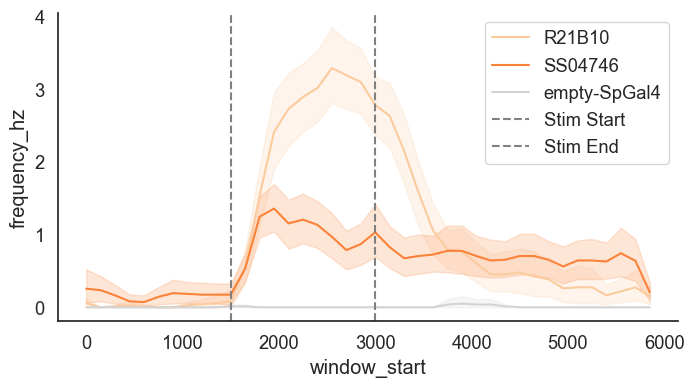

In [15]:
sns.set(style='white', font_scale =1.2)
fig,ax = plt.subplots(figsize=(8,4))

sns.lineplot(data=sweep_frequency_through_time, x='window_start', y='frequency_hz', 
                hue='genotype',palette=color_dict, markers=False, dashes=False)

ax.axvline(x=1500, color='gray', linestyle='--', label='Stim Start')
ax.axvline(x=3000, color='gray', linestyle='--', label='Stim End')
ax.legend()


# Remove the top and right boundary of the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


### How do the genotypes vary by grooming strategy

In [16]:
mode_df = df.groupby(['genotype','fly','fullfile','sweep_number_new','other_leg']).size().reset_index(name='count')
mode_df = mode_df.query('sweep_number_new > 0')
legs = ['L1', 'L2', 'R1']
mode_df = mode_df.query('other_leg in @legs')
mode_df = mode_df.groupby(['genotype','fly','fullfile','other_leg']).size().reset_index(name='sweep_count')

In [17]:
# Group by genotype, flyid, and other_leg to calculate the total sweep_count for each leg
leg_sweep_totals = mode_df.groupby(['genotype', 'fly', 'other_leg'])['sweep_count'].sum().reset_index()

# Group by genotype and flyid to calculate the total sweeps for each fly
fly_sweep_totals = mode_df.groupby(['genotype', 'fly'])['sweep_count'].sum().reset_index()
fly_sweep_totals.rename(columns={'sweep_count': 'total_sweeps'}, inplace=True)

# Merge the leg totals with the fly totals
leg_sweep_proportions = leg_sweep_totals.merge(fly_sweep_totals, on=['genotype', 'fly'])

# Calculate the proportion of sweeps for each leg
leg_sweep_proportions['proportion'] = leg_sweep_proportions['sweep_count'] / leg_sweep_proportions['total_sweeps']


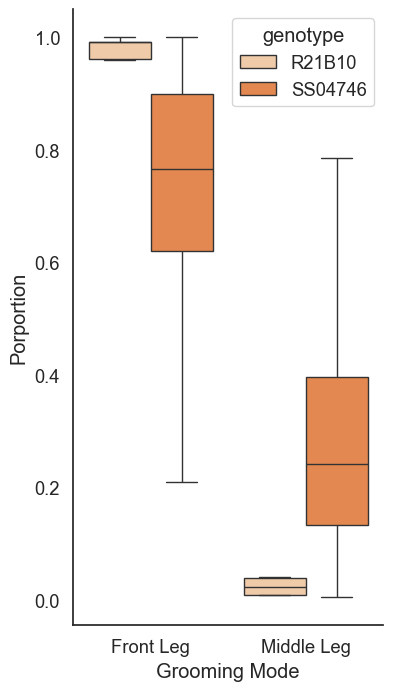

In [18]:
fig, ax = plt.subplots(figsize=(4, 8))

sns.boxplot(x='other_leg', y='proportion', hue = 'genotype',
            data=leg_sweep_proportions.query('genotype != "empty-SpGal4"'), 
            palette=color_dict,ax=ax,showfliers=False)

ax.set_ylabel('Porportion')
ax.set_xticklabels(['Front Leg', 'Middle Leg'])
ax.set_xlabel('Grooming Mode')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.show()

### Is there spatial variability between grooming modes?

Adding the annotated points for the first contact points of sweeps from different grooming modes across flies. Each contact point organized into four different modes. The first is middle leg grooming which involves grooming the front left leg with the middle left leg. Front leg grooming is split into three modes: Mode 1 involves both front legs grooming the tips, Mode 2 is the front right leg being brought across the midline to groom the front left leg, Mode 3 is the opposite bringing the front left leg across to groom the front right leg.

For each contact point, we triangulated these points into the same space as the leg tracking and calculated the nearest point on the front left leg as the contact point location.

In [19]:
complete_pts = pd.read_parquet('../data/labeled_first_contact_points.parquet')

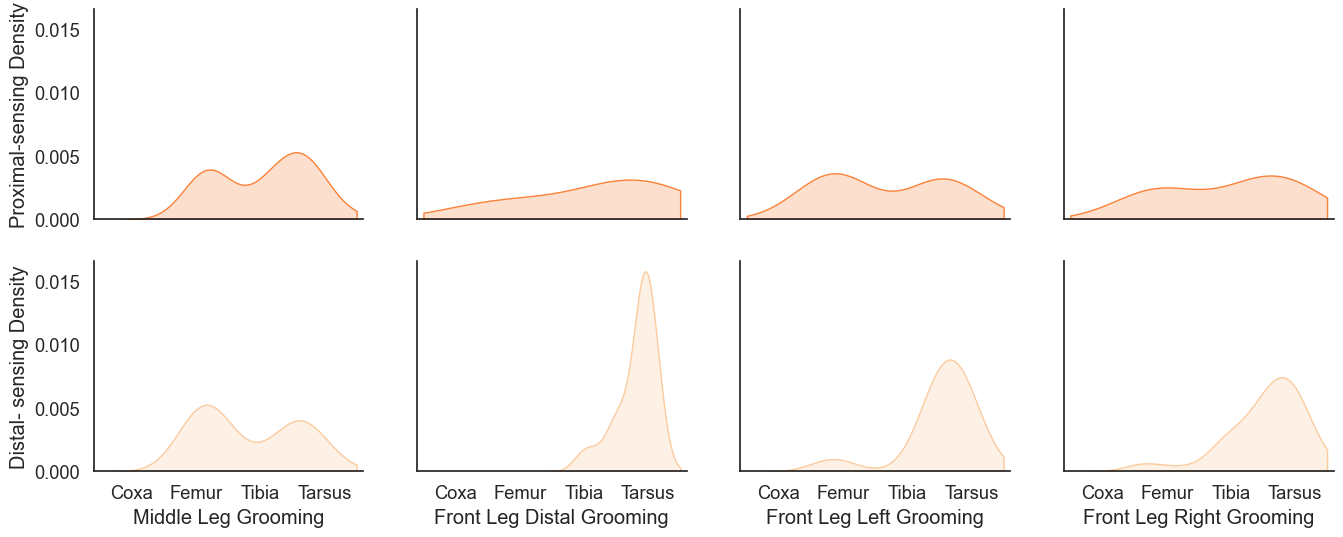

In [20]:
fig, ax = plt.subplots(2,4,figsize=(16, 6), sharex=True, sharey=True)
sns.kdeplot(data=complete_pts.query('genotype == "SS04746" & other_leg_adj == "L2"'), ax=ax[0,0],
            x='closest_index', color=color_dict['SS04746'], fill=True, common_norm=False, clip=(0,400))

sns.kdeplot(data=complete_pts.query('genotype == "SS04746" & root_leg_man == "Both"'), ax=ax[0,1],
            x='closest_index', color=color_dict['SS04746'], fill=True, common_norm=False, clip=(0,400))

sns.kdeplot(data=complete_pts.query('genotype == "SS04746" & other_leg_adj == "L1"'), ax=ax[0,2],
            x='closest_index', color=color_dict['SS04746'], fill=True, common_norm=False, clip=(0,400))

sns.kdeplot(data=complete_pts.query('genotype == "SS04746" & other_leg_adj == "R1"'), ax=ax[0,3],
            x='other_closest_index', color=color_dict['SS04746'], fill=True, common_norm=False, clip=(0,400))


sns.kdeplot(data=complete_pts.query('genotype == "R21B10" & other_leg_adj == "L2"'), ax=ax[1,0],
            x='closest_index', color=color_dict['R21B10'], fill=True, common_norm=False, clip=(0,400))

sns.kdeplot(data=complete_pts.query('genotype == "R21B10" & root_leg_man == "Both"'), ax=ax[1,1],
            x='closest_index', color=color_dict['R21B10'], fill=True, common_norm=False, clip=(0,400))

sns.kdeplot(data=complete_pts.query('genotype == "R21B10" & other_leg_adj == "L1"'), ax=ax[1,2],
            x='closest_index', color=color_dict['R21B10'], fill=True, common_norm=False, clip=(0,400))

sns.kdeplot(data=complete_pts.query('genotype == "R21B10" & other_leg_adj == "R1"'), ax=ax[1,3],
            x='other_closest_index', color=color_dict['R21B10'], fill=True, common_norm=True, clip=(0,400))

for i in range(2):
    for j in range(4):
        ax[i, j].set_xlim(-10, 410)
        ax[i,j].set_ylabel('')
        ax[i,j].set_xticks([50,150,250,350])
        ax[i,j].set_xticklabels(['Coxa','Femur','Tibia','Tarsus'])
        ax[i,j].set_xlabel('')
        ax[i, j].spines['top'].set_visible(False)
        ax[i, j].spines['right'].set_visible(False)

ax[0,0].set_ylabel('Proximal-sensing Density')
ax[1,0].set_ylabel('Distal- sensing Density')

ax[1,0].set_xlabel('Middle Leg Grooming')
ax[1,1].set_xlabel('Front Leg Distal Grooming')
ax[1,2].set_xlabel('Front Leg Left Grooming')
ax[1,3].set_xlabel('Front Leg Right Grooming')
plt.show()


### Summary of spatial targetting for each genotype

In [21]:
#Helper Functions
def get_simulated_sweeps(complete_pts, leg_sweep_proportions, sample_size=10):
    """
    Simulate the sweep data weighted by the grooming mode proportions for each genotype.
    
    Parameters:
    - complete_pts: DataFrame containing complete points with 'genotype', 'other_leg', and 'fly'.
    - leg_sweep_proportions: DataFrame containing the proportions of sweeps for each leg.
    
    Returns:
    - sim: DataFrame containing the simulated sweep data.
    """
    import numpy as np
    import pandas as pd

    # Initialize an empty DataFrame to store the simulated data
    sim = pd.DataFrame()

    # Iterate over each genotype and sample the sweeps based on the proportions
    for genotype in ['SS04746', 'R21B10']:
        subset = leg_sweep_proportions.query('genotype == @genotype')
        sampled_fly = subset['fly'].sample(n=1, random_state=42).iloc[0]
        
        r1_prop = subset.query('other_leg == "R1" & fly == @sampled_fly')['proportion'].values[0]
        if r1_prop == 1.0:
            samples = complete_pts.query('genotype == @genotype & other_leg == "R1"').sample(n=sample_size, replace=False)
        else:
            l2_prop = subset.query('other_leg == "L2" & fly == @sampled_fly')['proportion'].values[0]
            l2_count = int(np.round(10 * l2_prop))
            r1_count = sample_size - l2_count
            samples = pd.concat([
                complete_pts.query('genotype == @genotype & other_leg == "R1"').sample(n=r1_count, replace=False),
                complete_pts.query('genotype == @genotype & other_leg == "L2"').sample(n=l2_count, replace=False)
            ])
        
        sim = pd.concat([sim, samples.assign(genotype=genotype)])
    
    return sim

def get_hundred_sim(sample_size = 10):
    """
    Generate 100 simulated sweeps from the annotated sweeps weighted by grooming mode proportions.
    
    Returns:
    - all_sim: DataFrame containing all simulated sweeps.
    """

    # Initialize an empty DataFrame to store all simulated sweeps
    all_sim = pd.DataFrame()

    # Iterate to generate 100 simulations
    for ix in range(100):
        sim = get_simulated_sweeps(complete_pts, leg_sweep_proportions, sample_size=sample_size)
        sim['sim_ix'] = ix
        if ix == 0:
            all_sim = sim.copy()
        else:
            all_sim = pd.concat([all_sim, sim]) 
    
    return all_sim




In [22]:
#This will generate 100 simulations with 10 sweeps each, 
# weighted by the grooming mode proportions for each genotype.
all_sim = get_hundred_sim(sample_size=10) 

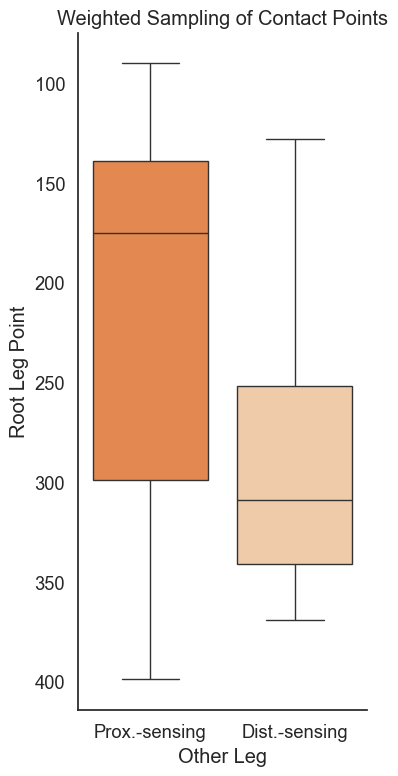

In [23]:
fig, axes = plt.subplots(figsize=(4, 8))

# # Define the order of the xlabels and the colors
order = ['SS04746','R21B10']

sns.boxplot(data=all_sim, x='genotype', showfliers=False,
              y='closest_index',  palette=color_dict, order=order)

axes.set_title('Weighted Sampling of Contact Points')
axes.set_xlabel('Other Leg')
axes.set_xticklabels(['Prox.-sensing', 'Dist.-sensing'])
axes.set_ylabel('Root Leg Point')
axes.invert_yaxis()

axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Below is a plot to visualize the variablity between each simulation

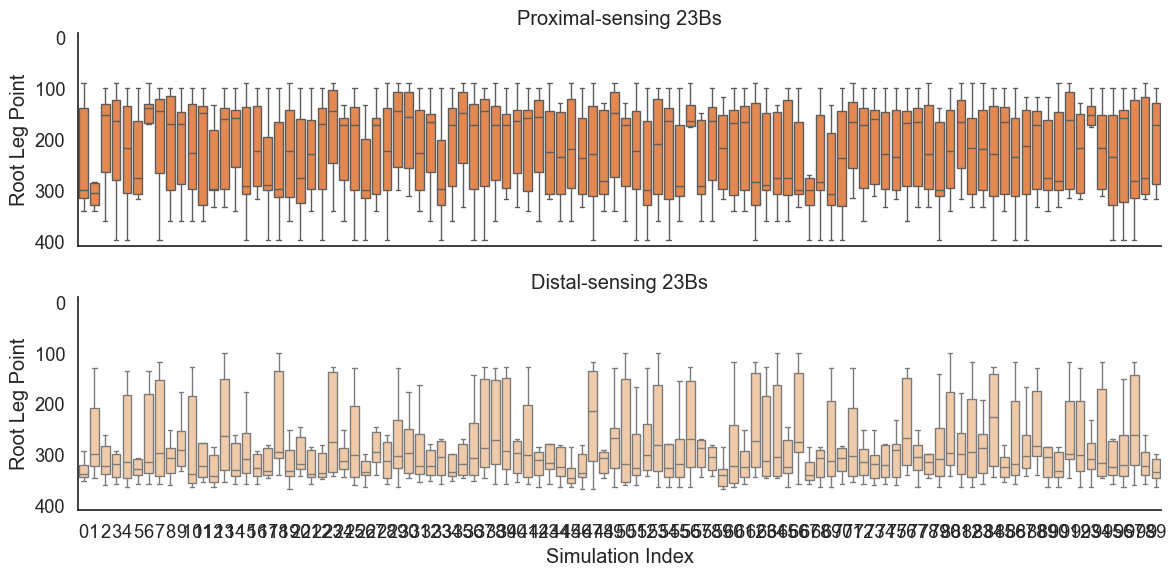

In [24]:
fig, axes = plt.subplots(2,1, figsize=(12, 6))

sns.boxplot(data=all_sim.query('genotype == "SS04746"'), x='sim_ix', ax=axes[0],
              y='closest_index',  color=color_dict['SS04746'],showfliers=False)
sns.boxplot(data=all_sim.query('genotype == "R21B10"'), x='sim_ix', ax=axes[1],
              y='closest_index',  color=color_dict['R21B10'],showfliers=False)
axes[0].set_title('Proximal-sensing 23Bs')
axes[0].set_ylim(410,-10)
axes[0].set_ylabel('Root Leg Point')
axes[0].set_xlabel('')
axes[0].set_xticklabels([])

axes[1].set_title('Distal-sensing 23Bs')
axes[1].set_ylabel('Root Leg Point')
axes[1].set_xlabel('Simulation Index')
axes[1].set_ylim(410,-10)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

The code below illustrates how we calculated the contact point distance on the leg.

In [ ]:
def get_contact_dist(fullfile, fnum, prefixes=['L1']):
    subset = complete_pts.query('fullfile == @fullfile & fnum == @fnum')
    pt = subset['contact_pt'].values[0]  # Get the contact point for the specified sample and frame
    # if pt.shape[0] > 1:
    #     pt = pt[:1]
    pt = np.array(pt).reshape(1,3)  # Ensure pt is a numpy array
    suffix = ''
    leg_vector_dict = {}

    for prefix in prefixes:
        leg_points = [f'{prefix}{joint}_pt_position{suffix}' for joint in ['A','B', 'C', 'D', 'E']]
        leg_vectors = []

        for i in range(len(leg_points) - 1):
            start_point = np.vstack(subset[leg_points[i]].values)
            end_point = np.vstack(subset[leg_points[i + 1]].values)
            vector = np.linspace(start_point, end_point, num=100, axis=1)
            leg_vectors.append(vector)

        # Combine all vectors and include original joint positions
        leg_vectors = np.hstack(leg_vectors)
        leg_vector_dict[prefix] = leg_vectors

    leg = prefixes[0]  # Assuming we are only interested in the first leg
    leg_1 = leg_vector_dict[leg][0, :, :]  # Extract the first leg's vectors
    #print(leg_1.shape, pt.shape,subset.blind_id.values[0])
    # Calculate the closest point on the vector to the contact point
    distances = cdist(leg_1, pt)  # Compute pairwise distances between leg_1 points and pt
    closest_index = np.argmin(distances)  # Find the index of the closest point
    #print(closest_index, distances.shape)
    dist = np.min(distances)  # Get the distance to the closest point
    closest_point = leg_1[closest_index,:]  # Retrieve the closest point
    return closest_index, dist, closest_point

In [ ]:
# Code run to calculate those points across first contacts
# for ix, i in complete_pts.iterrows():
#     fullfile = i['fullfile']
#     fnum = i['fnum']
#     closest_index, dist,closest_point = get_contact_dist(fullfile, fnum)
#     complete_pts.at[ix, 'closest_index'] = closest_index
#     complete_pts.at[ix, 'contact_distance'] = dist
#     complete_pts.at[ix, 'closest_point_x'] = closest_point[0]
#     complete_pts.at[ix, 'closest_point_y'] = closest_point[1]
#     complete_pts.at[ix, 'closest_point_z'] = closest_point[2]

#     other = i['other_leg']
#     other_closest_index, other_dist,other_closest_point = get_contact_dist(fullfile, fnum, prefixes=[other])
#     complete_pts.at[ix, 'other_closest_index'] = other_closest_index
#     complete_pts.at[ix, 'other_contact_distance'] = other_dist
#     complete_pts.at[ix, 'other_closest_point_x'] = other_closest_point[0]
#     complete_pts.at[ix, 'other_closest_point_y'] = other_closest_point[1]
#     complete_pts.at[ix, 'other_closest_point_z'] = other_closest_point[2]